In [14]:
# Memuat semua library yang dibutuhkan untuk proses training dan testing model
# pada MNIST Handwritten Digits Dataset
import torch
import torch.nn as nn
import torch.nn.functional as func
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch.optim as optim
from torch.optim import Adam

# image cnversion
from PIL import Image
import numpy as np
import torch
import torch.nn.functional as F
# Pengaturan untuk menentukan device komputasi yang akan digunakan
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Perisapan Data

In [15]:
# Mengunduh dataset (Images & Labels) dan memasukkannya ke dalam variable
train_dataset = datasets.MNIST(root ='./data', train = True,
transform = transforms.ToTensor(),
download = True)
train_data, val_data = random_split(train_dataset, [50000, 10000])
test_data = datasets.MNIST(root ='./data', train = False,
transform = transforms.ToTensor(), download = True)

In [16]:
# Mengecek ukuran dari setiap kelompok data
print("Ukuran training set : {}x{}x{}x{}x{}".format(len(train_data), len(train_data[0]),
len(train_data[0][0]), len(train_data[0][0][0]),
len(train_data[0][0][0][0])))
print("Ukuran validation set : {}x{}x{}x{}x{}".format(len(val_data), len(val_data[0]),
len(val_data[0][0]), len(val_data[0][0][0]),
len(val_data[0][0][0][0])))
print("Ukuran testing set : {}x{}x{}x{}x{}".format(len(test_data), len(test_data[0]),
len(test_data[0][0]), len(test_data[0][0][0]),
len(test_data[0][0][0][0])))
# Catatan:
# - Dimensi ke-0 = Banyaknya data
# - Dimensi ke-1 = Images[1x28x28] + Labels[1]

Ukuran training set : 50000x2x1x28x28
Ukuran validation set : 10000x2x1x28x28
Ukuran testing set : 10000x2x1x28x28


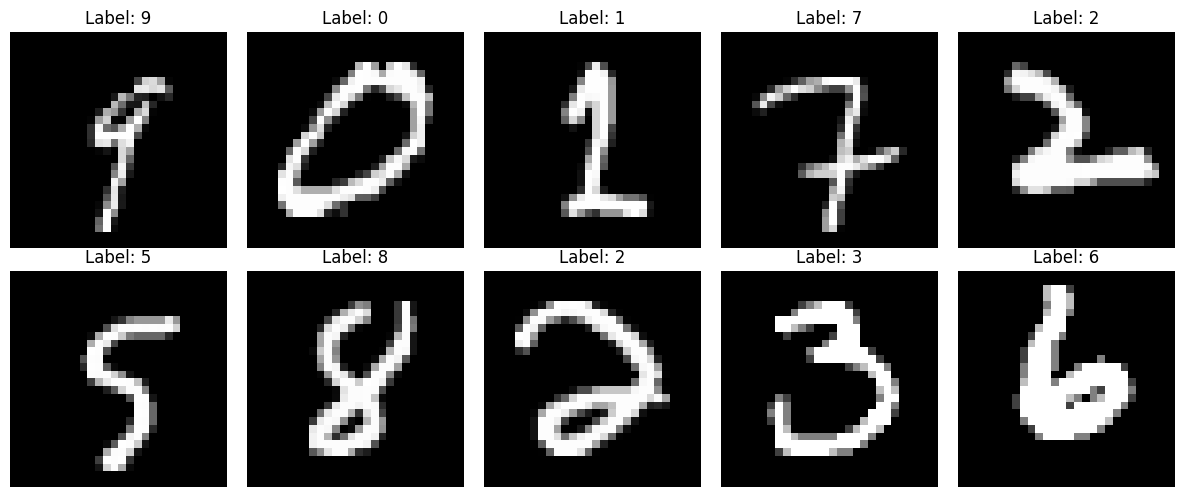

In [43]:
# Memilih 10 indeks data secara acak dari keseluruhan panjang training set
random_indices = np.random.choice(len(train_data), 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(random_indices):
    # Mengambil gambar dan label dari tuple PyTorch Dataset
    image, label = train_data[idx]
    
    # Image saat ini berbentuk Tensor [1, 28, 28]. 
    # Kita hapus dimensi channel '1' dengan squeeze(), lalu ubah menjadi numpy array
    image_np = image.squeeze().numpy()
    
    # Membuat subplot dengan format 2 baris dan 5 kolom
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_np, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Rancangan arsitektur Neural Network


In [18]:
# 5. Definisi Model CNN
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Layer 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Layer 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Flatten
        x = x.view(-1, 64 * 7 * 7)
        # Fully Connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Inisialisasi model
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [19]:
# 6. Loss Function dan Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

In [20]:
# 7. Training Loop
num_epochs = 20
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    if 'train_loader' not in globals():
        batch_size = 64
        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(test_loader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

Epoch [1/20], Train Loss: 0.2414, Train Acc: 92.58%, Val Loss: 0.0601, Val Acc: 98.08%
Epoch [2/20], Train Loss: 0.1132, Train Acc: 96.56%, Val Loss: 0.0374, Val Acc: 98.81%
Epoch [3/20], Train Loss: 0.0859, Train Acc: 97.43%, Val Loss: 0.0470, Val Acc: 98.58%
Epoch [4/20], Train Loss: 0.0787, Train Acc: 97.66%, Val Loss: 0.0389, Val Acc: 98.76%
Epoch [5/20], Train Loss: 0.0636, Train Acc: 98.08%, Val Loss: 0.0379, Val Acc: 98.78%
Epoch [6/20], Train Loss: 0.0579, Train Acc: 98.19%, Val Loss: 0.0337, Val Acc: 98.93%
Epoch [7/20], Train Loss: 0.0539, Train Acc: 98.29%, Val Loss: 0.0281, Val Acc: 99.13%
Epoch [8/20], Train Loss: 0.0482, Train Acc: 98.52%, Val Loss: 0.0288, Val Acc: 99.13%
Epoch [9/20], Train Loss: 0.0411, Train Acc: 98.68%, Val Loss: 0.0279, Val Acc: 99.31%
Epoch [10/20], Train Loss: 0.0370, Train Acc: 98.79%, Val Loss: 0.0273, Val Acc: 99.12%
Epoch [11/20], Train Loss: 0.0370, Train Acc: 98.79%, Val Loss: 0.0370, Val Acc: 98.86%
Epoch [12/20], Train Loss: 0.0329, Train 

Final Test Accuracy: 99.36%


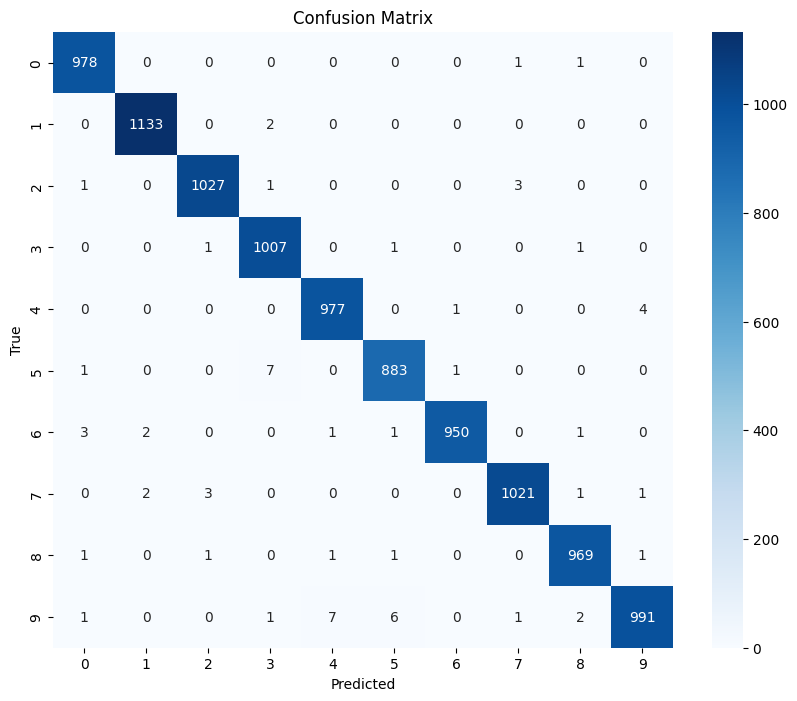


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [21]:
# 8. Evaluasi Model
# Test final accuracy
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

final_accuracy = 100 * correct / total
print(f'Final Test Accuracy: {final_accuracy:.2f}%')

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

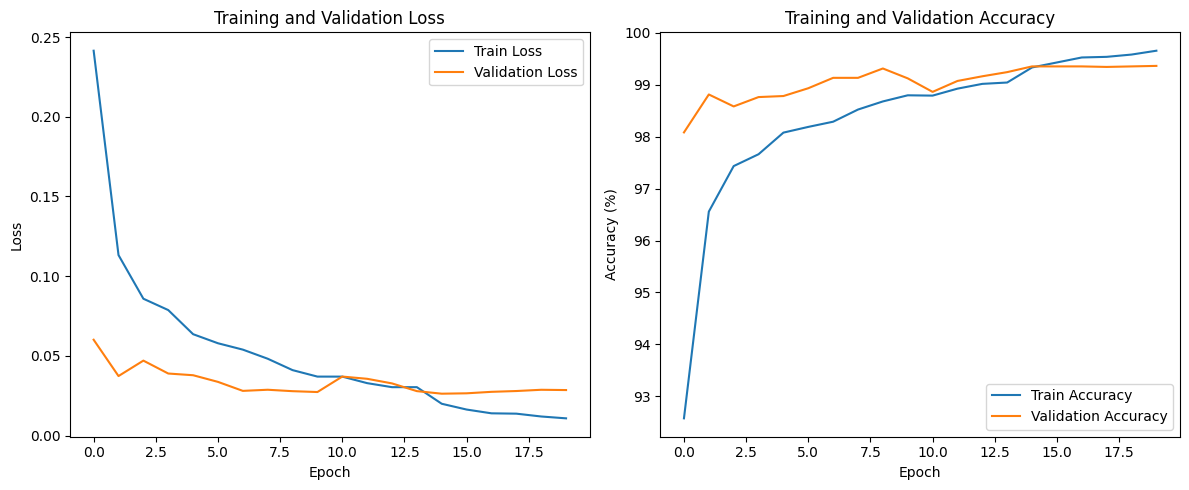

In [22]:
# 9. Visualisasi Hasil Training
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Model saved as 'mnist_cnn_model.pth'


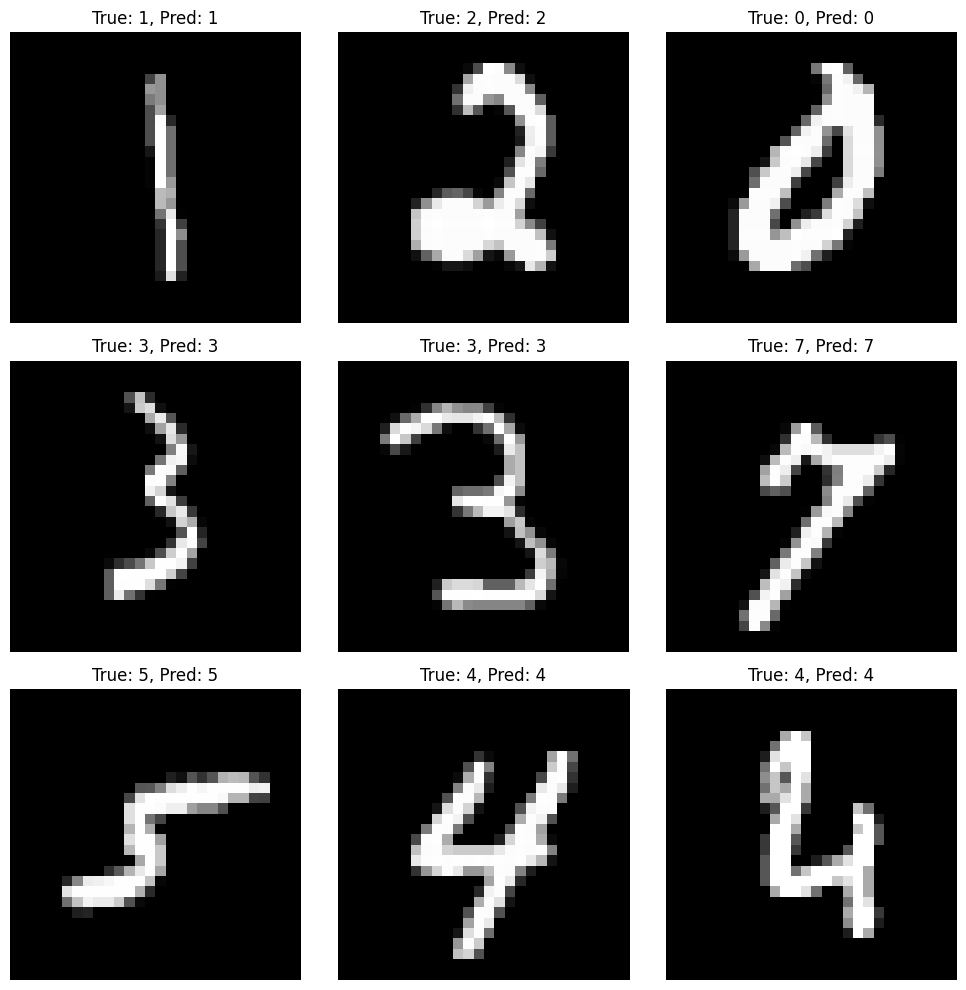

In [23]:
# 10. Simpan Model
torch.save(model.state_dict(), 'mnist_cnn_model.pth')
print("Model saved as 'mnist_cnn_model.pth'")

# 11. Contoh Prediksi
def predict_image(img, model):
    model.eval()
    with torch.no_grad():
        img = img.to(device)
        output = model(img.unsqueeze(0))  # Add batch dimension
        _, predicted = torch.max(output.data, 1)
        return predicted.item()

# Tampilkan beberapa contoh prediksi
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.ravel()

for i in range(9):
    idx = np.random.randint(len(test_data))
    img, label = test_data[idx]
    prediction = predict_image(img, model)
    
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'True: {label}, Pred: {prediction}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [49]:
# 12. Load Model dan Prediksi Data Baru (grayscale + edge detection)
# Load model yang sudah disimpan
loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load('mnist_cnn_model.pth', map_location=device))
loaded_model.eval()

# Fungsi untuk memproses gambar baru (umum untuk berbagai format)
def preprocess_image(image_path, image_size=(28, 28), apply_edge=True, invert=False, grayscale=True):
    # Buka gambar dan ubah menjadi grayscale
    img = Image.open(image_path).convert('L')
    img = img.resize(image_size)
    img_array = np.array(img, dtype=np.float32) / 255.0

    if grayscale:
        # sudah dalam mode grayscale ('L'), pastikan dtype dan rentang benar
        img_array = img_array.astype(np.float32)
    else:
        # buka ulang sebagai RGB lalu konversi ke grayscale (luminance)
        img_rgb = Image.open(image_path).convert('RGB').resize(image_size)
        img_rgb = np.array(img_rgb, dtype=np.float32) / 255.0
        img_array = 0.2989 * img_rgb[..., 0] + 0.5870 * img_rgb[..., 1] + 0.1140 * img_rgb[..., 2]

    if invert:
        img_array = 1.0 - img_array

    if apply_edge:
        img_tensor = torch.from_numpy(img_array).unsqueeze(0).unsqueeze(0)
        # Sobel kernels untuk edge detection
        sobel_x = torch.tensor([[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]], dtype=torch.float32)
        sobel_y = torch.tensor([[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]], dtype=torch.float32)
        sobel = torch.cat([sobel_x, sobel_y], dim=0).unsqueeze(1)
        edges = F.conv2d(img_tensor, sobel, padding=1)
        # Magnitudo gradien
        edges = torch.sqrt(edges[:, 0:1] ** 2 + edges[:, 1:2] ** 2)
        edges = edges.squeeze(0)
        # Normalisasi ke 0..1 dan tingkatkan intensitas
        max_val = edges.max()
        if max_val > 0:
            edges = edges / max_val
        edges = torch.pow(edges, 0.2)  # Increase intensity by power operation
        img_tensor = edges
    else:
        img_array = np.power(img_array, 0.2)  # Increase intensity
        img_tensor = torch.from_numpy(img_array).unsqueeze(0)

    return img_tensor


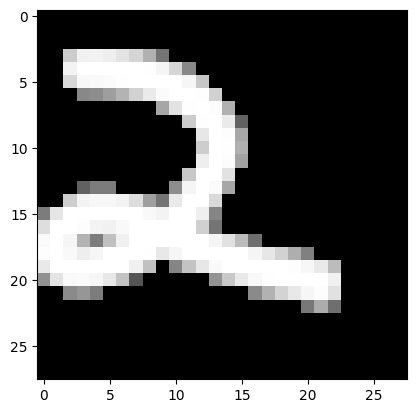

In [45]:
image_path = 'image.png'
processed_img = preprocess_image(image_path, image_size=(28, 28), apply_edge=False, invert=True)
# display processed image
plt.imshow(processed_img.squeeze(), cmap='gray')

In [46]:

prediction = predict_image(processed_img, loaded_model)
print(f'Predicted digit: {prediction}')

Predicted digit: 2


In [27]:
# dari proses predict image


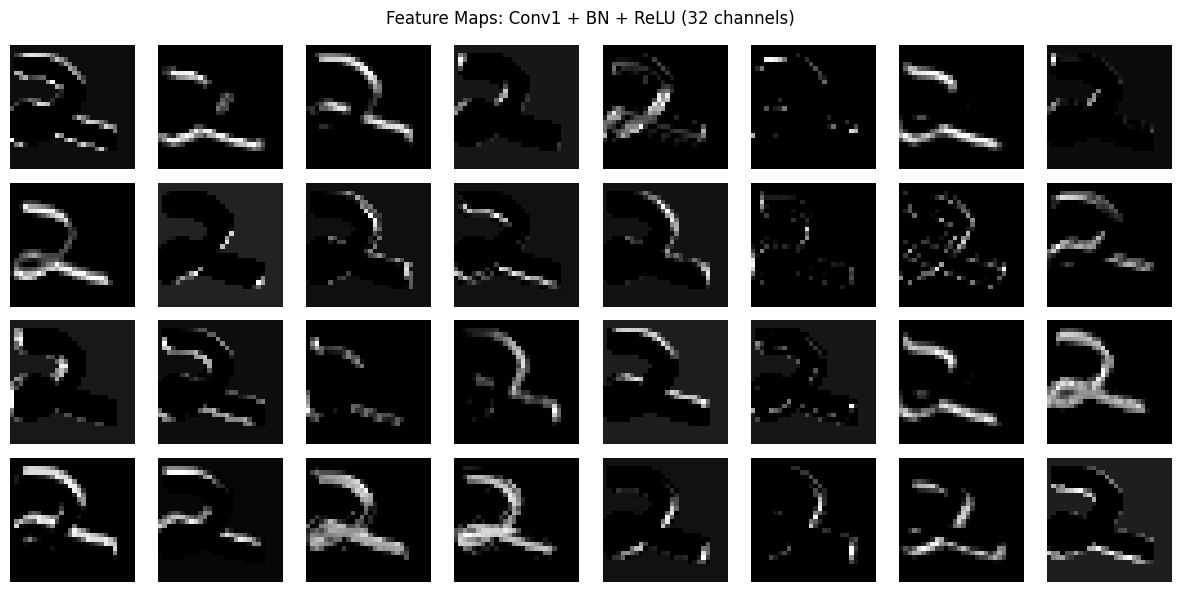

In [47]:
# Visualisasi feature map setelah Conv1 + BN + ReLU (32 channel)
with torch.no_grad():
    x = processed_img.to(device)
    if x.dim() == 3:
        x = x.unsqueeze(0)  # add batch dimension
    x = loaded_model.conv1(x)
    x = loaded_model.bn1(x)
    x = F.relu(x)
    feature_maps = x.squeeze(0).cpu()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    fmap = feature_maps[i]
    fmap_min, fmap_max = fmap.min(), fmap.max()
    if fmap_max > fmap_min:
        fmap = (fmap - fmap_min) / (fmap_max - fmap_min)
    ax.imshow(fmap, cmap='gray')
    ax.axis('off')
plt.suptitle('Feature Maps: Conv1 + BN + ReLU (32 channels)')
plt.tight_layout()
plt.show()

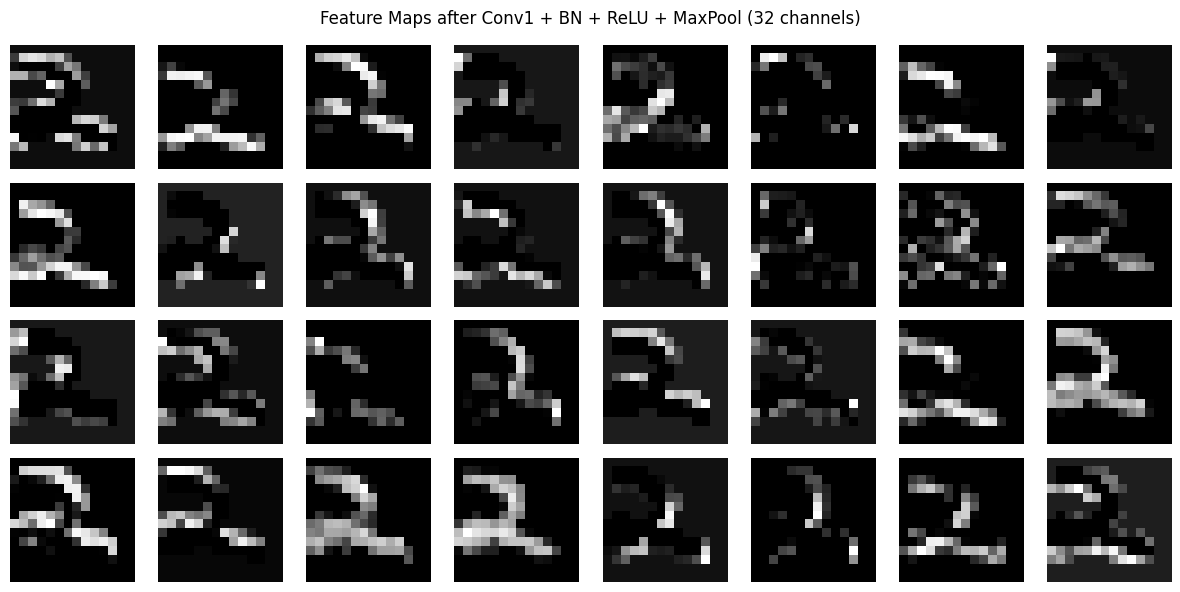

In [48]:
# Visualisasi feature map setelah MaxPool pertama (Conv1 -> BN -> ReLU -> Pool)
with torch.no_grad():
    x = processed_img.to(device)
    if x.dim() == 3:
        x = x.unsqueeze(0)  # add batch dimension
    x = loaded_model.conv1(x)
    x = loaded_model.bn1(x)
    x = F.relu(x)
    x = loaded_model.pool(x)  # first max pool
    feature_maps = x.squeeze(0).cpu()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    fmap = feature_maps[i]
    fmap_min, fmap_max = fmap.min(), fmap.max()
    if fmap_max > fmap_min:
        fmap = (fmap - fmap_min) / (fmap_max - fmap_min)
    ax.imshow(fmap, cmap='gray')
    ax.axis('off')
plt.suptitle('Feature Maps after Conv1 + BN + ReLU + MaxPool (32 channels)')
plt.tight_layout()
plt.show()

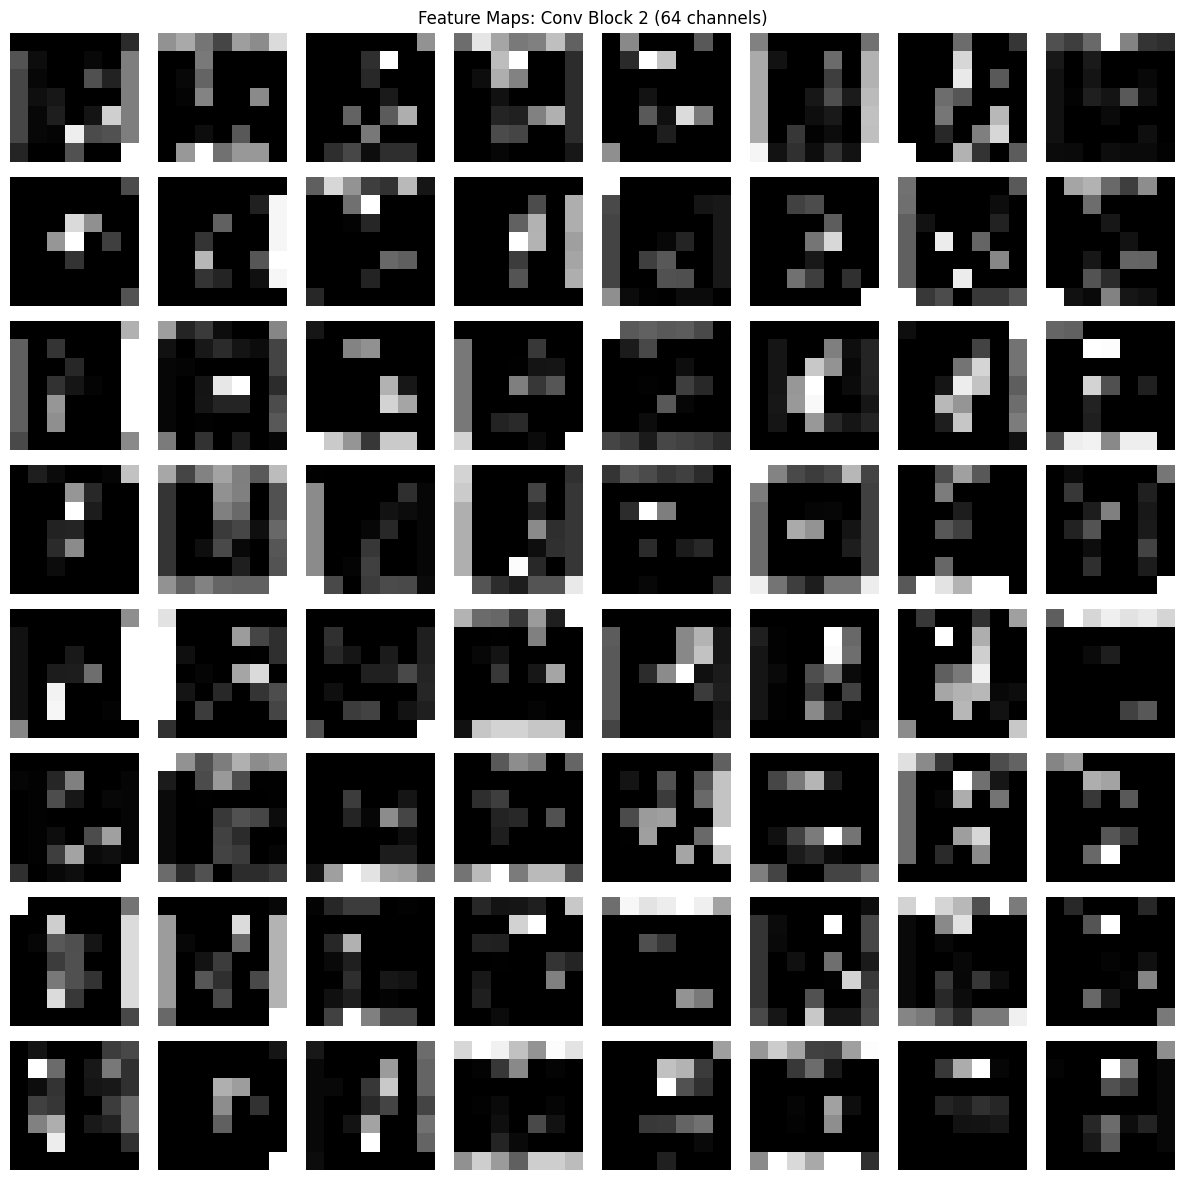

In [29]:
# Visualisasi feature map setelah Conv Block 2 (64 channel)
with torch.no_grad():
    x = processed_img.to(device)
    if x.dim() == 3:
        x = x.unsqueeze(0)  # add batch dimension
    x = loaded_model.pool(F.relu(loaded_model.bn1(loaded_model.conv1(x))))
    x = loaded_model.pool(F.relu(loaded_model.bn2(loaded_model.conv2(x))))
    feature_maps = x.squeeze(0).cpu()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    fmap = feature_maps[i]
    fmap_min, fmap_max = fmap.min(), fmap.max()
    if fmap_max > fmap_min:
        fmap = (fmap - fmap_min) / (fmap_max - fmap_min)
    ax.imshow(fmap, cmap='gray')
    ax.axis('off')
plt.suptitle('Feature Maps: Conv Block 2 (64 channels)')
plt.tight_layout()
plt.show()